# Регрессия CC50

Ноутбук подготовлен для запуска в Google Colab. Сначала загрузите файл `drug_data.xlsx`, затем запускайте ячейки по порядку.

In [3]:
# Установка библиотек для Google Colab
!pip -q install xgboost lightgbm openpyxl seaborn


In [4]:
# Загрузка исходного файла с данными

import os
from google.colab import files

DATA_PATH = '/content/drug_data.xlsx'

if not os.path.exists(DATA_PATH):
    uploaded = files.upload()
    if 'drug_data.xlsx' not in uploaded:

        first_file = next(iter(uploaded.keys()))
        os.rename(first_file, DATA_PATH)

os.makedirs('reports', exist_ok=True)
os.makedirs('models', exist_ok=True)
print(f'Файл данных: {DATA_PATH}')
print('Папки reports/ и models/ готовы')


Файл данных: /content/drug_data.xlsx
Папки reports/ и models/ готовы


## Основной код

РЕГРЕССИЯ ДЛЯ ПРОГНОЗИРОВАНИЯ CC50
Размер данных: (1001, 210)
Целевая переменная: CC50
Диапазон CC50: [0.701, 4538.976]
Медиана CC50: 411.039
Удаляем 18 константных признаков
Удаляем 32 высококоррелированных признаков
Итоговое количество признаков: 160
Обучающая выборка: (800, 160)
Тестовая выборка: (201, 160)

1. ОПРЕДЕЛЕНИЕ МОДЕЛЕЙ
----------------------------------------
Определено 11 моделей

2. КРОСС-ВАЛИДАЦИЯ МОДЕЛЕЙ
----------------------------------------
Обучение Linear Regression...
  RMSE: 89961.5503 ± 178805.6978
Обучение Ridge Regression...
  RMSE: 552.3999 ± 96.1313
Обучение Lasso Regression...
  RMSE: 504.1561 ± 25.3403
Обучение ElasticNet...
  RMSE: 674.0399 ± 305.0372
Обучение Random Forest...
  RMSE: 443.4789 ± 37.1991
Обучение Extra Trees...
  RMSE: 442.8437 ± 45.5844
Обучение Gradient Boosting...
  RMSE: 455.3297 ± 35.4383
Обучение XGBoost...
  RMSE: 477.7640 ± 57.7339
Обучение LightGBM...
  RMSE: 460.5658 ± 37.2308
Обучение SVR...
  RMSE: 642.7845 ± 59.1213
Обучени

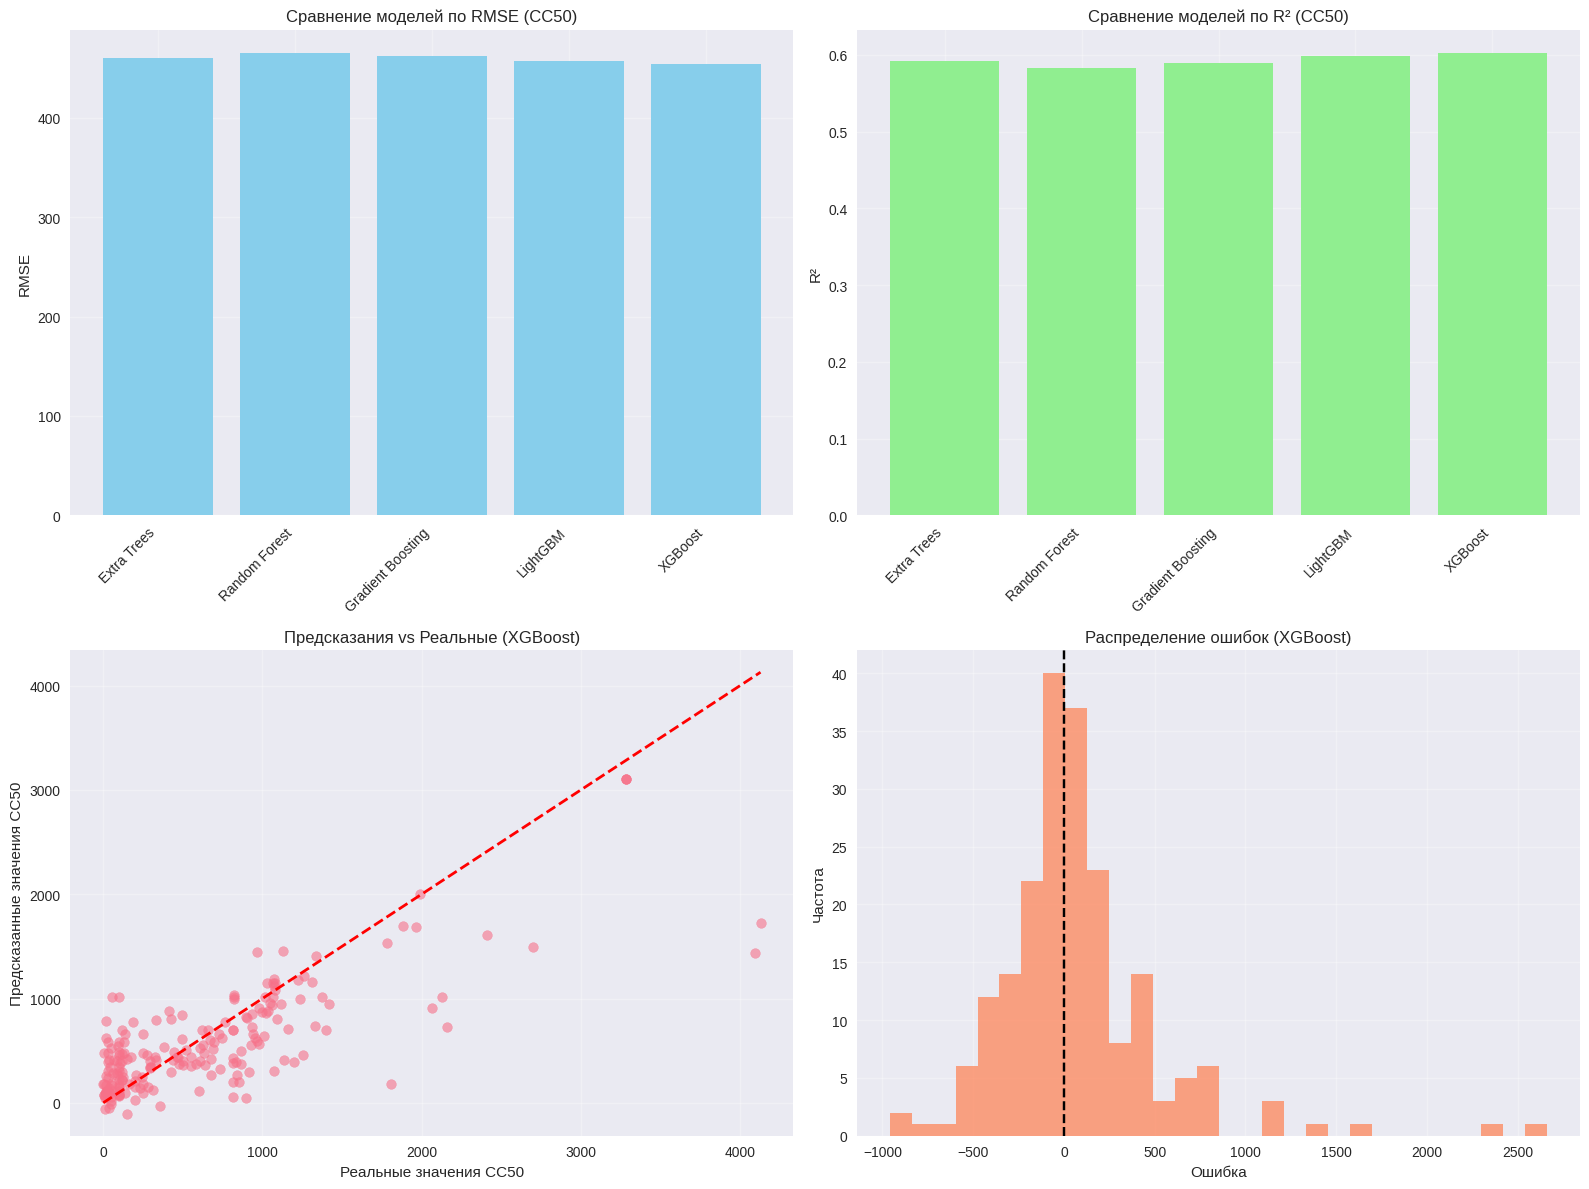


6. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
----------------------------------------
Результаты сохранены в папку reports/

МОДЕЛИРОВАНИЕ CC50 ЗАВЕРШЕНО!
Лучшая модель: XGBoost
RMSE: 454.0533


In [10]:
# Модели регрессии для прогнозирования CC50
# CC50 - концентрация препарата, токсичная для 50% клеток


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer # Import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_palette("husl")

class CC50Predictor:
    """Класс для прогнозирования CC50"""

    def __init__(self):
        self.models = {}
        self.results = {}
        self.best_model = None
        self.scaler = StandardScaler()

    def load_and_prepare_data(self):
        """Загрузка и подготовка данных"""
        print("="*60)
        print("РЕГРЕССИЯ ДЛЯ ПРОГНОЗИРОВАНИЯ CC50")
        print("="*60)

        # Загрузка данных
        df = pd.read_excel(DATA_PATH)

        # Переименование целевых столбцов
        df = df.rename(columns={'IC50, mM': 'IC50', 'CC50, mM': 'CC50'})

        # Удаление индексного столбца
        if 'Unnamed: 0' in df.columns:
            df = df.drop('Unnamed: 0', axis=1)

        # Разделение на признаки и целевую переменную
        self.target_col = 'CC50'
        feature_cols = [col for col in df.columns if col not in ['IC50', 'CC50', 'SI']]

        X = df[feature_cols].copy()
        y = df[self.target_col].copy()

        print(f"Размер данных: {X.shape}")
        print(f"Целевая переменная: {self.target_col}")
        print(f"Диапазон {self.target_col}: [{y.min():.3f}, {y.max():.3f}]")
        print(f"Медиана {self.target_col}: {y.median():.3f}")

        # Проверка и удаление константных признаков
        constant_features = X.columns[X.nunique() <= 1]
        if len(constant_features) > 0:
            print(f"Удаляем {len(constant_features)} константных признаков")
            X = X.drop(constant_features, axis=1)

        # Удаление высококоррелированных признаков
        corr_matrix = X.corr().abs()
        upper_triangle = np.triu(np.ones_like(corr_matrix), k=1)
        high_corr_pairs = np.where((corr_matrix > 0.95) & upper_triangle)

        features_to_remove = set()
        for i in range(len(high_corr_pairs[0])):
            idx1, idx2 = high_corr_pairs[0][i], high_corr_pairs[1][i]
            feature1, feature2 = X.columns[idx1], X.columns[idx2]
            corr1 = abs(np.corrcoef(X[feature1], y)[0,1])
            corr2 = abs(np.corrcoef(X[feature2], y)[0,1])
            if corr1 < corr2:
                features_to_remove.add(feature1)
            else:
                features_to_remove.add(feature2)

        if features_to_remove:
            print(f"Удаляем {len(features_to_remove)} высококоррелированных признаков")
            X = X.drop(list(features_to_remove), axis=1)

        print(f"Итоговое количество признаков: {X.shape[1]}")

        # Разделение на обучающую и тестовую выборки
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        print(f"Обучающая выборка: {self.X_train.shape}")
        print(f"Тестовая выборка: {self.X_test.shape}")

        return X, y

    def define_models(self):
        """Определение моделей для тестирования"""
        print(f"\n1. ОПРЕДЕЛЕНИЕ МОДЕЛЕЙ")
        print("-"*40)

        self.models = {
            'Linear Regression': Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', LinearRegression())
            ]),

            'Ridge Regression': Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', Ridge(random_state=42))
            ]),

            'Lasso Regression': Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', Lasso(random_state=42, max_iter=2000))
            ]),

            'ElasticNet': Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', ElasticNet(random_state=42, max_iter=2000))
            ]),

            'Random Forest': Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('model', RandomForestRegressor(
                    n_estimators=100, random_state=42 # removed n_jobs=-1
                ))
            ]),

            'Extra Trees': Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('model', ExtraTreesRegressor(
                    n_estimators=100, random_state=42 # removed n_jobs=-1
                ))
            ]),

            'Gradient Boosting': Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('model', GradientBoostingRegressor(
                    random_state=42
                ))
            ]),

            'XGBoost': Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('model', xgb.XGBRegressor(
                    random_state=42, verbosity=0 # removed n_jobs=-1
                ))
            ]),

            'LightGBM': Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('model', lgb.LGBMRegressor(
                    random_state=42, verbosity=-1 # removed n_jobs=-1
                ))
            ]),

            'SVR': Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', SVR(kernel='rbf'))
            ]),

            'Neural Network': Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', MLPRegressor(random_state=42, max_iter=500))
            ])
        }

        print(f"Определено {len(self.models)} моделей")

    def evaluate_models(self):
        """Оценка всех моделей с кросс-валидацией"""
        print(f"\n2. КРОСС-ВАЛИДАЦИЯ МОДЕЛЕЙ")
        print("-"*40)

        cv = KFold(n_splits=5, shuffle=True, random_state=42)

        for name, model in self.models.items():
            print(f"Обучение {name}...")

            cv_scores = cross_val_score(
                model, self.X_train, self.y_train,
                cv=cv, scoring='neg_mean_squared_error', n_jobs=1 # Changed n_jobs to 1
            )

            rmse_scores = np.sqrt(-cv_scores)

            self.results[name] = {
                'cv_rmse_mean': rmse_scores.mean(),
                'cv_rmse_std': rmse_scores.std(),
                'cv_scores': rmse_scores
            }

            print(f"  RMSE: {rmse_scores.mean():.4f} \u00b1 {rmse_scores.std():.4f}")

        sorted_models = sorted(
            self.results.items(),
            key=lambda x: x[1]['cv_rmse_mean']
        )

        print(f"\nРАНГИ МОДЕЛЕЙ:")
        for i, (name, metrics) in enumerate(sorted_models, 1):
            print(f"{i:2d}. {name:<20} | RMSE: {metrics['cv_rmse_mean']:.4f}")

        return sorted_models

    def hyperparameter_tuning(self, top_models=3):
        """Настройка гиперпараметров для лучших моделей"""
        print(f"\n3. НАСТРОЙКА ГИПЕРПАРАМЕТРОВ")
        print("-"*40)

        sorted_models = sorted(
            self.results.items(),
            key=lambda x: x[1]['cv_rmse_mean']
        )

        param_grids = {
            'Random Forest': {
                'model__n_estimators': [50, 100, 200],
                'model__max_depth': [10, 20, None],
                'model__min_samples_split': [2, 5, 10]
            },

            'XGBoost': {
                'model__n_estimators': [50, 100, 200],
                'model__max_depth': [3, 6, 10],
                'model__learning_rate': [0.01, 0.1, 0.2]
            },

            'LightGBM': {
                'model__n_estimators': [50, 100, 200],
                'model__max_depth': [3, 6, 10],
                'model__learning_rate': [0.01, 0.1, 0.2]
            },

            'Ridge Regression': {
                'model__alpha': [0.1, 1.0, 10.0, 100.0]
            },

            'Lasso Regression': {
                'model__alpha': [0.001, 0.01, 0.1, 1.0]
            }
        }

        tuned_models = {}

        for name, _ in sorted_models[:top_models]:
            if name in param_grids:
                print(f"Настройка {name}...")

                grid_search = GridSearchCV(
                    self.models[name],
                    param_grids[name],
                    cv=3,
                    scoring='neg_mean_squared_error',
                    n_jobs=1 # Changed n_jobs to 1
                )

                grid_search.fit(self.X_train, self.y_train)

                tuned_models[name] = {
                    'model': grid_search.best_estimator_,
                    'best_params': grid_search.best_params_,
                    'best_score': -grid_search.best_score_
                }

                print(f"  Лучший RMSE: {np.sqrt(-grid_search.best_score_):.4f}")
            else:
                model = self.models[name]
                model.fit(self.X_train, self.y_train)

                tuned_models[name] = {
                    'model': model,
                    'best_params': {},
                    'best_score': 0
                }

        return tuned_models

    def final_evaluation(self, tuned_models):
        """Финальная оценка на тестовой выборке"""
        print(f"\n4. ФИНАЛЬНАЯ ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ")
        print("-"*40)

        final_results = {}

        for name, model_info in tuned_models.items():
            model = model_info['model']

            y_pred = model.predict(self.X_test)

            rmse = np.sqrt(mean_squared_error(self.y_test, y_pred))
            mae = mean_absolute_error(self.y_test, y_pred)
            r2 = r2_score(self.y_test, y_pred)

            final_results[name] = {
                'model': model,
                'y_pred': y_pred,
                'rmse': rmse,
                'mae': mae,
                'r2': r2
            }

            print(f"{name}:")
            print(f"  RMSE: {rmse:.4f}")
            print(f"  MAE:  {mae:.4f}")
            print(f"  R\u00b2:   {r2:.4f}")

        best_model_name = min(final_results.keys(),
                             key=lambda x: final_results[x]['rmse'])
        self.best_model = final_results[best_model_name]['model']

        print(f"\nЛУЧШАЯ МОДЕЛЬ: {best_model_name}")

        return final_results, best_model_name

    def create_visualizations(self, final_results, best_model_name):
        """Создание визуализаций результатов"""
        print(f"\n5. СОЗДАНИЕ ВИЗУАЛИЗАЦИЙ")
        print("-"*40)

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Сравнение RMSE
        model_names = list(final_results.keys())
        rmse_values = [final_results[name]['rmse'] for name in model_names]

        axes[0, 0].bar(range(len(model_names)), rmse_values, color='skyblue')
        axes[0, 0].set_xticks(range(len(model_names)))
        axes[0, 0].set_xticklabels(model_names, rotation=45, ha='right')
        axes[0, 0].set_ylabel('RMSE')
        axes[0, 0].set_title('Сравнение моделей по RMSE (CC50)')
        axes[0, 0].grid(True, alpha=0.3)

        # Сравнение R\u00B2
        r2_values = [final_results[name]['r2'] for name in model_names]

        axes[0, 1].bar(range(len(model_names)), r2_values, color='lightgreen')
        axes[0, 1].set_xticks(range(len(model_names)))
        axes[0, 1].set_xticklabels(model_names, rotation=45, ha='right')
        axes[0, 1].set_ylabel('R\u00b2')
        axes[0, 1].set_title('Сравнение моделей по R\u00b2 (CC50)')
        axes[0, 1].grid(True, alpha=0.3)

        # Предсказания vs реальные значения
        best_results = final_results[best_model_name]
        y_pred = best_results['y_pred']

        axes[1, 0].scatter(self.y_test, y_pred, alpha=0.6)
        axes[1, 0].plot([self.y_test.min(), self.y_test.max()],
                       [self.y_test.min(), self.y_test.max()], 'r--', lw=2)
        axes[1, 0].set_xlabel('Реальные значения CC50')
        axes[1, 0].set_ylabel('Предсказанные значения CC50')
        axes[1, 0].set_title(f'Предсказания vs Реальные ({best_model_name})')
        axes[1, 0].grid(True, alpha=0.3)

        # Распределение ошибок
        errors = self.y_test - y_pred

        axes[1, 1].hist(errors, bins=30, alpha=0.7, color='coral')
        axes[1, 1].axvline(0, color='black', linestyle='--')
        axes[1, 1].set_xlabel('Ошибка')
        axes[1, 1].set_ylabel('Частота')
        axes[1, 1].set_title(f'Распределение ошибок ({best_model_name})')
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('reports/cc50_regression_results.png', dpi=300, bbox_inches='tight')
        plt.show()

    def save_results(self, final_results, best_model_name):
        """Сохранение результатов"""
        print(f"\n6. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
        print("-"*40)

        # Сохраняем результаты в CSV
        results_summary = []
        for name, metrics in final_results.items():
            results_summary.append({
                'Model': name,
                'RMSE': metrics['rmse'],
                'MAE': metrics['mae'],
                'R2': metrics['r2']
            })

        results_df = pd.DataFrame(results_summary)
        results_df.to_csv('reports/cc50_regression_results.csv', index=False)

        # Сохраняем предсказания лучшей модели
        predictions_df = pd.DataFrame({
            'True_CC50': self.y_test.values,
            'Predicted_CC50': final_results[best_model_name]['y_pred'],
            'Error': self.y_test.values - final_results[best_model_name]['y_pred']
        })
        predictions_df.to_csv('reports/cc50_predictions.csv', index=False)

        print("Результаты сохранены в папку reports/")

def main():
    """Основная функция для обучения моделей регрессии CC50"""

    predictor = CC50Predictor()

    X, y = predictor.load_and_prepare_data()
    predictor.define_models()
    sorted_models = predictor.evaluate_models()
    tuned_models = predictor.hyperparameter_tuning(top_models=5)
    final_results, best_model_name = predictor.final_evaluation(tuned_models)
    predictor.create_visualizations(final_results, best_model_name)
    predictor.save_results(final_results, best_model_name)

    print(f"\nМОДЕЛИРОВАНИЕ CC50 ЗАВЕРШЕНО!")
    print(f"Лучшая модель: {best_model_name}")
    print(f"RMSE: {final_results[best_model_name]['rmse']:.4f}")

if __name__ == "__main__":
    main()